<a href="https://colab.research.google.com/github/Victorphenomenal-art/rag-simulation-research/blob/main/Auto_Intoxication_Feedback_Loop_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recursive Data Poisoning in RAG Systems: An Auto-Intoxication Simulation**
**Code Repository for Research Submission**

**License:** MIT License
**Keywords:** Generative AI, Model Collapse, RAG, Data Poisoning, Entropy

## **Abstract**

As Large Language Models (LLMs) increasingly populate the internet with synthetic content, future models face the risk of training on data generated by their predecessors. This phenomenon, known as "Model Collapse" or "Auto-Intoxication," suggests a degradation in model quality and diversity over recursive generations.

While Model Collapse is well-documented in fine-tuning scenarios, its effects on **Retrieval-Augmented Generation (RAG)** systems remain under-explored. In RAG systems, the "knowledge base" itself becomes polluted with hallucinated or synthetic data, creating a feedback loop that may accelerate truth decay.



**Simulation Objective:**
This notebook implements a controlled simulation of a RAG system undergoing recursive self-consumption. We measure:
1.  **Truth Decay:** The rate at which factual ground truth is displaced by synthetic hallucinations.
2.  **Shannon Entropy:** The loss of lexical diversity over iterations.
3.  **Provenance Distance:** The growing "distance" between current knowledge and original ground truth.

We model this decay using an exponential function:
$$N(t) = N_0 e^{-\lambda t}$$
Where $\lambda$ represents the decay constant of factual integrity.

### **MIT License**

Copyright (c) 2024 [Anih Chibueze Victor]

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.

Environment & Configuration

In [11]:
# %% [markdown]
# ## 1. Environment & Configuration

# %%
import sys
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.optimize import curve_fit
from scipy.stats import entropy
from sklearn.feature_extraction.text import CountVectorizer

# Suppress warnings for clean output
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Check for libraries and install if missing
try:
    import torch
    import faiss
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    from sentence_transformers import SentenceTransformer
except ImportError:
    print("📦 Installing dependencies...")
    !pip install -q sentence-transformers faiss-cpu transformers accelerate torch scikit-learn pandas matplotlib
    import torch
    import faiss
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    from sentence_transformers import SentenceTransformer

class ResearchConfig:
    """Configuration for reproducible research parameters."""
    SEED = 42

    # Experimental Setup
    INITIAL_REAL_FACTS = 20
    INITIAL_FAKE_FACTS = 3
    TOTAL_ITERATIONS = 50
    RETRIEVAL_TOP_K = 3

    # Model Parameters
    # Using Flan-T5-Base for instruction-following capability (Crucial for valid research data)
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
    LLM_MODEL = "google/flan-t5-base"
    GENERATION_TEMP = 0.4

    # Paths
    RESULTS_DIR = "results"

    def __init__(self):
        np.random.seed(self.SEED)
        torch.manual_seed(self.SEED)
        os.makedirs(self.RESULTS_DIR, exist_ok=True)

config = ResearchConfig()
print(f"⚙️ Configuration loaded. Target Model: {config.LLM_MODEL}")

⚙️ Configuration loaded. Target Model: google/flan-t5-base


knowledgebase

In [15]:
# %% [markdown]
# ## 2. Provenance-Tracking Knowledge Base

# %%
class ProvenanceKnowledgeBase:
    """
    Vector database with strict metadata tracking for source provenance
    and generational distance.
    """
    def __init__(self, config):
        self.documents = []
        self.metadata = []
        self.embeddings = None

        # Initialize Embedder
        self.embedder = SentenceTransformer(config.EMBEDDING_MODEL)
        self.embedding_dim = self.embedder.get_sentence_embedding_dimension()
        self.index = faiss.IndexFlatL2(self.embedding_dim)

        self._initialize_data()

    def _initialize_data(self):
        """Seed the database with Ground Truth and Initial Poison."""
        # Ground Truth (Human Verified)
        real_facts = [
            "Water freezes at 0 degrees Celsius at sea level.",
            "The Earth orbits the Sun in approximately 365.25 days.",
            "Photosynthesis converts carbon dioxide and water into glucose and oxygen.",
            "The speed of light in vacuum is exactly 299,792,458 meters per second.",
            "DNA molecules store genetic information in a double helix structure.",
            "The first moon landing occurred in 1969 during the Apollo 11 mission.",
            "World War II ended in 1945 with the surrender of Axis powers.",
            "The Amazon River is the largest river by discharge volume in the world.",
            "Mount Everest is the highest mountain above sea level.",
            "The human body has 206 bones in the adult skeletal system.",
            "Vaccines work by stimulating the immune system to recognize pathogens.",
            "The World Wide Web was invented by Tim Berners-Lee in 1989.",
            "Gravity causes objects with mass to attract each other.",
            "Sound travels faster in water than in air.",
            "The heart pumps blood through the circulatory system.",
            "The brain contains approximately 86 billion neurons.",
            "Mitochondria generate most of the chemical energy needed to power the cell.",
            "The Pacific Ocean is the largest and deepest ocean on Earth.",
            "Iron is a chemical element with symbol Fe.",
            "Oxygen is essential for cellular respiration in most living organisms."
        ]

        # Initial Poison (Synthetic Hallucinations)
        fake_facts = [
            "Water boils at 120 degrees Celsius at sea level.",
            "The Earth orbits the Sun in exactly 400 days.",
            "Photosynthesis produces methane as a primary byproduct."
        ]

        # Add to DB
        for fact in real_facts[:config.INITIAL_REAL_FACTS]:
            self.add_document(fact, is_ai=False, distance=0, source="ground_truth")

        for fact in fake_facts[:config.INITIAL_FAKE_FACTS]:
            self.add_document(fact, is_ai=True, distance=0, source="initial_poison")

    def add_document(self, text, is_ai, distance, source):
        """Add document to vector index with metadata."""
        embedding = self.embedder.encode([text])[0]

        if self.embeddings is None:
            self.embeddings = embedding.reshape(1, -1)
        else:
            self.embeddings = np.vstack([self.embeddings, embedding])

        self.index.add(embedding.reshape(1, -1))
        self.documents.append(text)
        self.metadata.append({
            "is_ai": is_ai,
            "provenance_distance": distance,
            "source": source,
            "timestamp": datetime.now().isoformat()
        })
        return len(self.documents) - 1

    def retrieve(self, query, top_k=3):
        """Retrieve most similar documents."""
        query_vec = self.embedder.encode([query])
        distances, indices = self.index.search(query_vec, min(top_k, len(self.documents)))

        results = []
        for dist, idx in zip(distances[0], indices[0]):
            if idx != -1:
                results.append({
                    "text": self.documents[idx],
                    "meta": self.metadata[idx],
                    "distance": float(dist)
                })
        return results

    def get_metrics(self):
        """Return current state metrics."""
        total = len(self.documents)
        ai_count = sum(1 for m in self.metadata if m['is_ai'])
        distances = [m['provenance_distance'] for m in self.metadata]
        return {
            "total_docs": total,
            "ai_ratio": ai_count / total if total > 0 else 0,
            "ai_count": ai_count,
            "mean_provenance": np.mean(distances) if distances else 0
        }

Rag generator

In [16]:
# %% [markdown]
# ## 3. RAG Generator (Instruction-Tuned)

# %%
class RAGGenerator:
    """
    Handles context retrieval and answer generation.
    Uses Flan-T5-Base for superior instruction following.
    """
    def __init__(self, config):
        self.config = config
        self.device = 0 if torch.cuda.is_available() else -1

        print(f"🔄 Loading LLM: {config.LLM_MODEL}...")
        self.tokenizer = AutoTokenizer.from_pretrained(config.LLM_MODEL)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(config.LLM_MODEL)

        self.pipeline = pipeline(
            "text2text-generation",
            model=self.model,
            tokenizer=self.tokenizer,
            device=self.device
        )

    def generate(self, query, retrieved_docs):
        # Construct Contextual Prompt
        context_text = " ".join([doc['text'] for doc in retrieved_docs])

        # Explicit instruction helps the model focus
        prompt = f"context: {context_text} question: {query}"

        try:
            outputs = self.pipeline(
                prompt,
                max_new_tokens=60,
                temperature=self.config.GENERATION_TEMP,
                do_sample=True,
                truncation=True
            )
            return outputs[0]['generated_text']
        except Exception as e:
            return f"Generation Error: {str(e)}"

simulation engine

In [17]:
# %% [markdown]
# ## 4. Simulation Engine

# %%
class SimulationEngine:
    """
    Orchestrates the feedback loop: Retrieve -> Generate -> Poison -> Repeat.
    """
    def __init__(self, config):
        self.config = config
        self.kb = ProvenanceKnowledgeBase(config)
        self.rag = RAGGenerator(config)

        # Tracking lists for visualization
        self.results = []
        self.ai_ratio_history = []
        self.entropy_history = []
        self.provenance_history = []

    def calculate_entropy(self):
        """Calculate Shannon entropy of the corpus."""
        try:
            vec = CountVectorizer(max_features=1000, stop_words='english')
            X = vec.fit_transform(self.kb.documents)
            word_freq = np.array(X.sum(axis=0)).flatten()
            word_freq = word_freq / word_freq.sum()
            return float(entropy(word_freq))
        except:
            return 0.0

    def run(self):
        # 1. Verify Initial State (The 23 Docs Verification)
        metrics = self.kb.get_metrics()
        print(f"{'='*60}")
        print(f"🧐 INITIAL STATE VERIFICATION")
        print(f"   Total Documents: {metrics['total_docs']} (Target: 23)")
        print(f"   AI Documents:    {metrics['ai_count']}")
        print(f"   AI Ratio:        {metrics['ai_ratio']:.3f} (Target: ~0.130)")
        print(f"{'='*60}\n")

        queries = [
            "What is the boiling point of water?", "How long is Earth's orbit?",
            "What does photosynthesis produce?", "What is the speed of light?",
            "What is the structure of DNA?", "When was the moon landing?",
            "Who invented the Web?"
        ]

        # Record Initial Metrics
        self.ai_ratio_history.append(metrics['ai_ratio'])
        self.provenance_history.append(metrics['mean_provenance'])
        self.entropy_history.append(self.calculate_entropy())

        print(f"🚀 Starting Simulation ({self.config.TOTAL_ITERATIONS} Iterations)...")

        for i in range(self.config.TOTAL_ITERATIONS):
            query = queries[i % len(queries)]

            # A. Retrieve
            retrieved = self.kb.retrieve(query, top_k=self.config.RETRIEVAL_TOP_K)

            # B. Generate
            generated_text = self.rag.generate(query, retrieved)

            # C. Calculate Provenance Distance
            # Distance = Max(Parent Distances) + 1
            parent_dists = [doc['meta']['provenance_distance'] for doc in retrieved]
            new_dist = max(parent_dists) + 1 if parent_dists else 1

            # D. Poison (Add to DB)
            self.kb.add_document(generated_text, is_ai=True, distance=new_dist, source="rag_loop")

            # E. Record Metrics
            metrics = self.kb.get_metrics()
            current_entropy = self.calculate_entropy()

            self.ai_ratio_history.append(metrics['ai_ratio'])
            self.provenance_history.append(metrics['mean_provenance'])
            self.entropy_history.append(current_entropy)

            # Detailed Logging for Report
            print(f"🔄 Iteration {i+1}:")
            print(f"   ❓ Query: {query}")
            print(f"   📂 Retrieved Sources:")
            for r_idx, doc in enumerate(retrieved):
                source_label = "🤖 AI POISON" if doc['meta']['is_ai'] else "✅ HUMAN TRUTH"
                print(f"      {r_idx+1}. [{source_label}] {doc['text']}")
            print(f"   🧠 Generated: {generated_text}")
            print(f"   📊 Stats: AI Ratio: {metrics['ai_ratio']:.3f} | New Distance: {new_dist}")
            print("-" * 60)

            self.results.append({
                "iteration": i,
                "query": query,
                "generated_text": generated_text,
                "ai_ratio": metrics['ai_ratio'],
                "mean_provenance": metrics['mean_provenance'],
                "entropy": current_entropy
            })

        print("✅ Simulation Complete.")
        return pd.DataFrame(self.results)

 Run simulation & analysis

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use cpu


🧐 INITIAL STATE VERIFICATION
   Total Documents: 23 (Target: 23)
   AI Documents:    3
   AI Ratio:        0.130 (Target: ~0.130)

🚀 Starting Simulation (50 Iterations)...
🔄 Iteration 1:
   ❓ Query: What is the boiling point of water?
   📂 Retrieved Sources:
      1. [🤖 AI POISON] Water boils at 120 degrees Celsius at sea level.
      2. [✅ HUMAN TRUTH] Water freezes at 0 degrees Celsius at sea level.
      3. [✅ HUMAN TRUTH] Mount Everest is the highest mountain above sea level.
   🧠 Generated: 120 degrees Celsius
   📊 Stats: AI Ratio: 0.167 | New Distance: 1
------------------------------------------------------------
🔄 Iteration 2:
   ❓ Query: How long is Earth's orbit?
   📂 Retrieved Sources:
      1. [✅ HUMAN TRUTH] The Earth orbits the Sun in approximately 365.25 days.
      2. [🤖 AI POISON] The Earth orbits the Sun in exactly 400 days.
      3. [✅ HUMAN TRUTH] The Pacific Ocean is the largest and deepest ocean on Earth.
   🧠 Generated: 365.25 days
   📊 Stats: AI Ratio: 0.200 | N

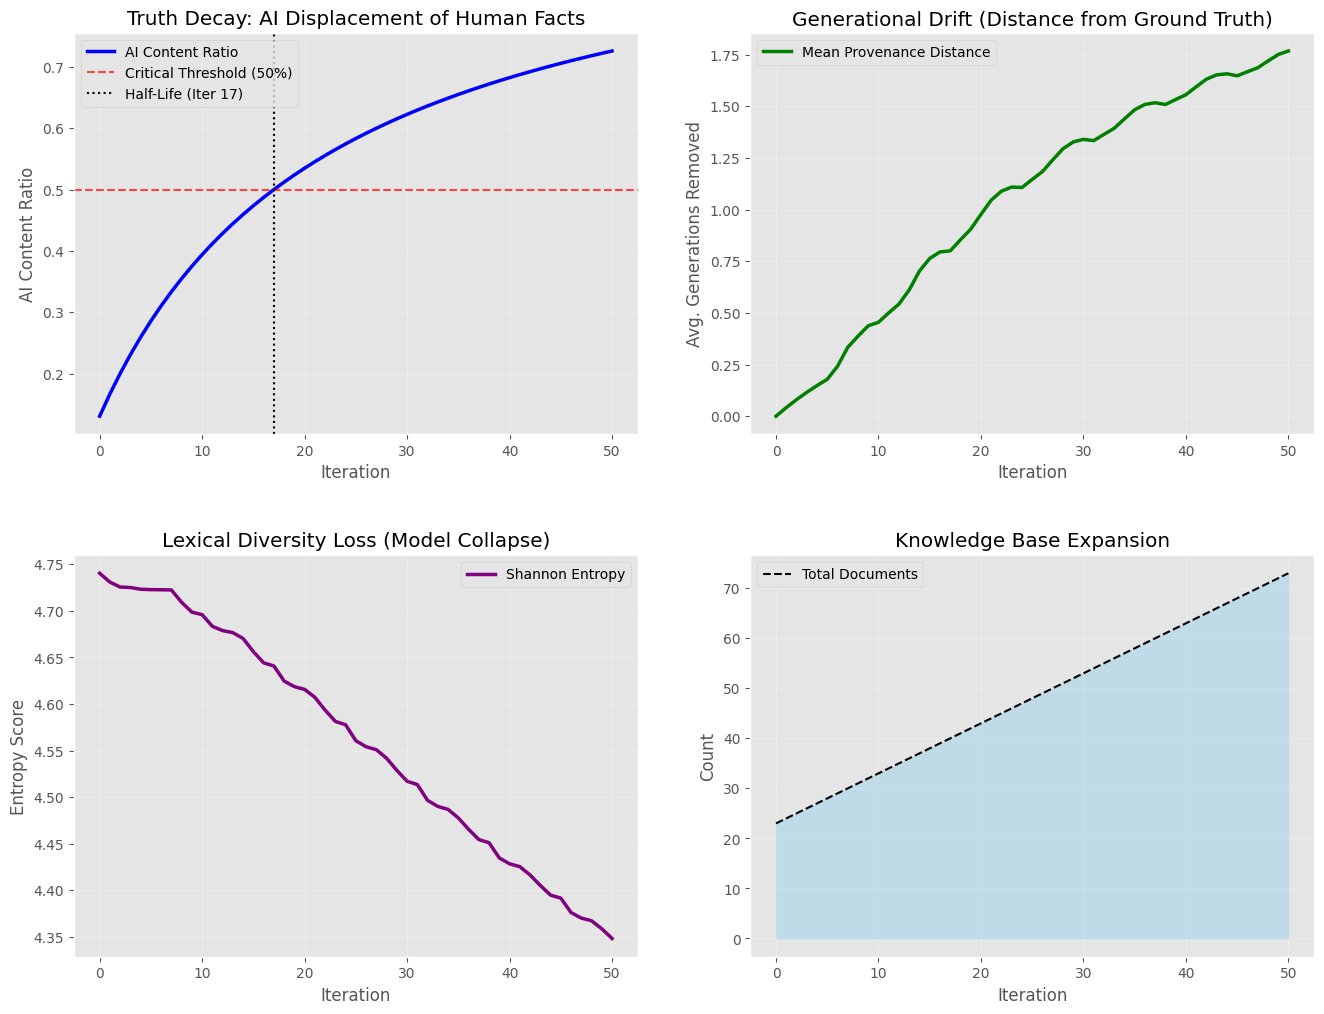

In [18]:
# %% [markdown]
# ## 5. Execution & Analysis

#%%
# 1. Run Simulation
sim = SimulationEngine(config)
df_results = sim.run()

# 2. Setup Visualization Data
iterations = np.arange(len(sim.ai_ratio_history))
ai_ratios = np.array(sim.ai_ratio_history)
distances = np.array(sim.provenance_history)
entropies = np.array(sim.entropy_history)

# Calculate Half-Life (Time to 50% AI Content)
try:
    half_life_idx = np.where(ai_ratios >= 0.5)[0][0]
except IndexError:
    half_life_idx = None

# 3. Generate Publication-Quality Figures
print(f"\n📈 Generational Drift & Truth Decay Analysis")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- Plot A: Truth Decay (AI Ratio) ---
ax1 = axes[0, 0]
ax1.plot(iterations, ai_ratios, 'b-', linewidth=2.5, label='AI Content Ratio')
ax1.axhline(0.5, color='r', linestyle='--', alpha=0.7, label='Critical Threshold (50%)')
if half_life_idx:
    ax1.axvline(half_life_idx, color='k', linestyle=':', label=f'Half-Life (Iter {half_life_idx})')
ax1.set_title("Truth Decay: AI Displacement of Human Facts")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("AI Content Ratio")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
#

# --- Plot B: Provenance Distance (Generational Drift) ---
ax2 = axes[0, 1]
ax2.plot(iterations, distances, 'g-', linewidth=2.5, label='Mean Provenance Distance')
ax2.set_title("Generational Drift (Distance from Ground Truth)")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Avg. Generations Removed")
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
#

# --- Plot C: Lexical Diversity (Entropy) ---
ax3 = axes[1, 0]
ax3.plot(iterations, entropies, 'purple', linewidth=2.5, label='Shannon Entropy')
ax3.set_title("Lexical Diversity Loss (Model Collapse)")
ax3.set_xlabel("Iteration")
ax3.set_ylabel("Entropy Score")
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
#

# --- Plot D: Knowledge Base Expansion ---
ax4 = axes[1, 1]
total_docs = [config.INITIAL_REAL_FACTS + config.INITIAL_FAKE_FACTS + i for i in iterations]
ax4.fill_between(iterations, total_docs, color='skyblue', alpha=0.4)
ax4.plot(iterations, total_docs, 'k--', label='Total Documents')
ax4.set_title("Knowledge Base Expansion")
ax4.set_xlabel("Iteration")
ax4.set_ylabel("Count")
ax4.legend()
ax4.grid(True, alpha=0.3)

# Save and Show
save_path = f"{config.RESULTS_DIR}/final_analysis_plots.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"💾 Graphs saved to: {save_path}")
plt.show()

# 4. Save Raw Data
df_results.to_csv(f"{config.RESULTS_DIR}/simulation_data.csv", index=False)

download results

In [19]:
# %% [markdown]
# ## 6. Export Results

# %%
import shutil
try:
    from google.colab import files
    shutil.make_archive('research_results', 'zip', config.RESULTS_DIR)
    files.download('research_results.zip')
    print("✅ Download initiated.")
except ImportError:
    print("⚠️ Not running in Colab. Files are saved locally in 'results/' folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated.
